<a href="https://colab.research.google.com/github/Nini11111111/basic-python/blob/main/Topics_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topics in Bioinformatics - Midterm Assigmnent 2
# Group 5: Aakriti Singh, Chunni Wang, Eftychia Daskalaki

In this assignment, we implement a program for constructing a suffix array from an input string. We then perform an experiment to measure running times on identical and random strings.

## 1. Program implementation

We first import the necessary libraries

In [ ]:
import time
import os
from functools import cmp_to_key
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


The function `cmp_suffix` is necessary in order to sort suffixes in lexicographical order. It takes two suffixes (as indices) and the string they come from and returns -1, 1, 0 in case the first one is smaller than, larger than, or equal to the second one respectively.

The function `suffix_array` takes a string as input and returns its suffix array. It first creates the suffixes (as indices of positions on the string) and then sorts them using the `cmp_suffix` as key function.

In [ ]:
# Function to compare two suffixes based on their lexicographical order
def cmp_suffix(i, j, s):
    # Compare suffix starting at index i with the suffix starting at index j
    if s[i:] < s[j:]:
        return -1
    elif s[i:] > s[j:]:
        return 1
    else:
        return 0

# Function to construct the suffix array
def suffix_array(s):
    n = len(s)
    suffixes = [i for i in range(n)]
    # Sort suffixes based on the comparison function
    sorted_suffixes = sorted(suffixes, key=cmp_to_key(lambda i, j: cmp_suffix(i, j, s)))
    return sorted_suffixes

## 2. Calling the function for a certain string

Below we have an example of the function call using the string "banana" as input. The output indicates the structure:
*   5: a
*   3: ana
*   1: anana
*   0: banana
*   4: na
*   2: nana

In [ ]:
# Example given in the assignment
s = "banana"
suffix_arr = suffix_array(s)
print("Suffix Array:", suffix_arr)

Suffix Array: [5, 3, 1, 0, 4, 2]


## 3. Worst case running time
Breaking down the steps of `suffix_array`, we end up with O(n^2*log(n)) running time:

*  `n = len(s)` *constant*
*  `suffixes = [i for i in range(n)]` *O(n)*
*   `sorted_suffixes = sorted(suffixes, key=cmp_to_key(lambda i, j: cmp_suffix(i, j, s)))` *Sorting takes O(nlog(n)) for O(n) pairs*

`cmp_to_key` has O(n) worst case running time. In theory, the more similar two strings are from left to right, the more time it will take the function to return a result. Based on this, we would expect identical strings to have higher running times.

## 4. Running time experiment

In the chunk below, we define two functions in order to read the input strings and measure running time for the `suffix_array` function.

`read_strings_from_directory`takes as input the directory that contains the strings of interest as `.txt` files and creates a list of them sorted based on length.

`measure_time_for_strings` takes as input the list of strings to be analysed, measures and prints the time it takes for `suffix_array` to run for each string. It returns a list of the lengths and a list of the corresponding running times for the strings.

In [ ]:
# Function to read all text files from a directory
def read_strings_from_directory(directory_path):
    strings = []
    for filename in os.listdir(directory_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory_path, filename)
            with open(file_path, 'r') as file:
                string = file.read().strip()  # Remove any trailing whitespace/newlines
                strings.append(string)
    strings = sorted(strings, key=len)
    return strings

# Function to measure the time to construct suffix array for a given list of strings
def measure_time_for_strings(strings, label):
    times = []
    lengths = []
    for s in strings:
        lengths.append(len(s))  # Store the length of each string for plotting
        start_time = time.time()
        suffix_array(s)
        end_time = time.time()
        times.append(end_time - start_time)
        print(f"{label} string of length {len(s)} took {end_time - start_time:.4f} seconds")
    return lengths, times


We define the directories of the input strings and loead them with the help of `read_strings_from_directory`

In [ ]:
identical_directory_path = "/content/drive/MyDrive/TiB_projects/all_a_str"
random_directory_path = "/content/drive/MyDrive/TiB_projects/random_str"


# Read strings from the identical strings directory
identical_strings = read_strings_from_directory(identical_directory_path)

# Read strings from the random strings directory
random_strings = read_strings_from_directory(random_directory_path)


In the code below we call `measure_time_for_strings` for the identical strings

In [ ]:
# Measure running time for identical strings
identical_lengths, identical_times = measure_time_for_strings(identical_strings, "Identical")

Identical string of length 10000 took 0.0102 seconds
Identical string of length 20000 took 0.0304 seconds
Identical string of length 30000 took 0.0499 seconds
Identical string of length 40000 took 0.0860 seconds
Identical string of length 50000 took 0.1290 seconds
Identical string of length 60000 took 0.1778 seconds
Identical string of length 70000 took 0.2387 seconds
Identical string of length 80000 took 0.3121 seconds
Identical string of length 90000 took 0.4422 seconds
Identical string of length 100000 took 0.5310 seconds
Identical string of length 200000 took 2.0506 seconds
Identical string of length 300000 took 4.2125 seconds
Identical string of length 400000 took 7.5770 seconds
Identical string of length 500000 took 13.7098 seconds
Identical string of length 600000 took 22.6341 seconds
Identical string of length 700000 took 33.4272 seconds
Identical string of length 800000 took 46.6873 seconds
Identical string of length 900000 took 62.6869 seconds
Identical string of length 10000

In the code below we call `measure_time_for_strings` for the random strings:

In [ ]:
# Measure running time for random strings
random_lengths, random_times = measure_time_for_strings(random_strings, "Random")

Random string of length 10000 took 0.1020 seconds
Random string of length 20000 took 0.3728 seconds
Random string of length 30000 took 0.8302 seconds
Random string of length 40000 took 1.4220 seconds
Random string of length 50000 took 2.1852 seconds
Random string of length 60000 took 3.2761 seconds
Random string of length 70000 took 4.5981 seconds
Random string of length 80000 took 5.4735 seconds
Random string of length 90000 took 7.4765 seconds
Random string of length 100000 took 8.9843 seconds
Random string of length 200000 took 37.3978 seconds
Random string of length 300000 took 92.5306 seconds
Random string of length 400000 took 173.9473 seconds
Random string of length 500000 took 288.0783 seconds
Random string of length 600000 took 432.7943 seconds
Random string of length 700000 took 611.7024 seconds
Random string of length 800000 took 820.0020 seconds
Random string of length 900000 took 1068.3591 seconds
Random string of length 1000000 took 1365.8328 seconds


We have kept record of the outputs of the `measure_time_for_strings` function for both identical and random strings and we use it to visualise the running time in relation to string length.

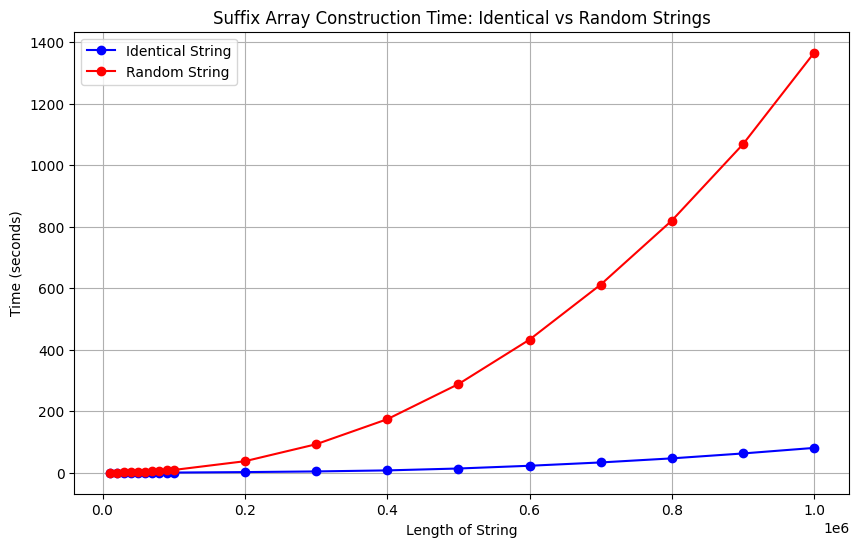

In [ ]:
# Plotting the results
plt.figure(figsize=(10, 6))

# Plot identical strings' times
plt.plot(identical_lengths, identical_times, label="Identical String", marker='o', color='blue')

# Plot random strings' times
plt.plot(random_lengths, random_times, label="Random String", marker='o', color='red')

# Add labels and title
plt.xlabel('Length of String')
plt.ylabel('Time (seconds)')
plt.title('Suffix Array Construction Time: Identical vs Random Strings')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

We notice that the running time for random strings is substantially higher than the running time for identical strings. This comes in contrast with our theoretical expectation. This result stems from **the way python handles string comparisons internally** when commands like `s[i:] < s[j:]` and `s[i:] > s[j:]` are called. If we **manually** coded string comparisons to run **position by position from left to right**, we would meet the theoretical running time expectation for identical and random strings.